In [10]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings
from pydantic import BaseModel

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import re

load_dotenv()

True

In [2]:
# 1)loading
docs = (
    PyPDFLoader("./documents/book1.pdf").load() +
    PyPDFLoader("./documents/book3.pdf").load()
)
len(docs)

1322

In [3]:
# 2) chunking
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError , to replace weird characters from pdf and run error free
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [4]:
len(chunks)

4117

In [28]:
# 4) embeddings & vector store & retriver
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = Chroma.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type='similarity' ,search_kwargs={'k':4})

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11549.31it/s]


In [29]:
# llm
llm = ChatGroq(model="llama-3.1-8b-instant")

In [30]:
class State(TypedDict):
    question : str
    docs : list[Document]
    # ⭐
    strips : list[str]      #decomposition output (sentences strips)
    kept_strips : list[str] #sentences to keep 
    refined_context : str   #knowledge internal (K internal)     

    answer : str

In [31]:
#node 1
def retrieves_docs(state:State) -> State:
    question = state['question']
    return {'docs': retriever.invoke(question)}

In [32]:
# node 2 (NEW NODE⭐)

# -----------------------------
# 1st part Sentence-level DECOMPOSER  (will split paragraph into list of sentences )
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

class keeporDROP(BaseModel):
    keep : bool

filter_prompt = ChatPromptTemplate([
    ("system",
    "You are a strict relevance filter.\n"
    "Return keep=true only if the sentence directly helps answer the question.\n"
    "Use ONLY the sentence. Output JSON only."),
    ("user","Question: {question}\n\nSentence:\n{sentence}")
])
# 2nd part

filter_chain = filter_prompt | llm.with_structured_output(keeporDROP)

# -------------------------------------------------------------------------------------
# REFINING (Decompose -> Filter -> Recompose)    MAIN refine NODE ⭐
# -------------------------------------------------------------------------------------
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [36]:
#node 3
prompt = ChatPromptTemplate([
    ("system",
    "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
    "If the bullets are empty or insufficient, say: 'I don't know based on the provided books."),
    ("user","Question: {question}\n\nRefined context:\n{refined_context}")
])

def generate(state:State) -> State:
    context = "\n\n".join(d.page_content for d in state['docs'])
    out = (prompt | llm).invoke({'question':state['question'],'refined_context':state['refined_context']}).content
    return {'answer':out}

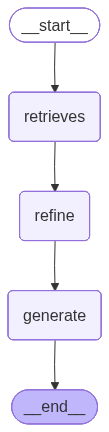

In [37]:
graph = StateGraph(State)

graph.add_node('retrieves',retrieves_docs)
graph.add_node('refine',refine)
graph.add_node('generate',generate)

graph.add_edge(START,'retrieves')
graph.add_edge('retrieves','refine')
graph.add_edge('refine','generate')
graph.add_edge('generate',END)

graph = graph.compile()

graph

In [38]:
result = graph.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})

print(result['answer'])

• The bias–variance tradeoff is a concept in machine learning that describes the balance between two types of errors: 
  - **Bias**: The difference between the average prediction and the true value, often due to oversimplification of the model.
  - **Variance**: The degree of variation in predictions that occur due to different data sets, often due to overfitting.

• The goal of a good model is to minimize both bias and variance to achieve low overall error.

• **High bias** and **low variance** result in a model that is too simple, and it fails to capture the underlying patterns in the data.

• **Low bias** and **high variance** result in a model that is too complex, and it overfits the training data but fails to generalize well to new data.

• Regularization (e.g., L1 and L2) can be used to control the bias-variance tradeoff by adding a penalty term to the loss function, which reduces overfitting (low bias, high variance) and improves generalization.


In [39]:
print(result['refined_context'])

The minimum value of (bias)2 + variance occurs around ln λ = −0.31, which is close to the value that gives the minimum error on the test data.
The top row corresponds to a large value of the regularization coefﬁcient λ that gives low variance (because the red curves in the left plot look similar) but high bias (because 3.2.
The minimum value of (bias)2 + variance occurs around ln λ = −0.31, which is close to the value that gives the minimum error on the test data.
The top row corresponds to a large value of the regularization coefﬁcient λ that gives low variance (because the red curves in the left plot look similar) but high bias (because with respect to multiple data sets.
We can also examine the bias-variance trade-off quantitatively for this example.
We can also examine the bias-variance trade-off quantitatively for this example.
